<a href="https://colab.research.google.com/github/MEdan-US/Mini-Project/blob/hai062/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 0: Prelimaniries

## Import and Configuration

Sử dụng thư viện nào thì điền ở đây, không ghi dưới code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings

sns.set_theme(style='whitegrid')
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Mute warnings
warnings.filterwarnings('ignore')
print('Import Library Successfully')

Import Library Successfully


## Prepare dataset

In [3]:
!gdown 1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh

Downloading...
From: https://drive.google.com/uc?id=1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh
To: /content/ai_student_impact_dataset.csv
100% 5.89M/5.89M [00:00<00:00, 28.9MB/s]


In [ ]:
DATA_PATH="/content/ai_student_impact_dataset.csv"
df=pd.read_csv(DATA_PATH,index_col="Student_ID")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       50

Biến Target là `Post_Semester GPA`

# Step 1: Exploratory Data Analysis

## Numerical Features (Mon)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu cụ thể (int64, float64).
  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) trên từng biến định lượng và đề xuất hướng xử lý (điền bằng mean, median hay xóa).
- Thống kê mô tả (Descriptive Statistics):
  - Tính toán các chỉ số cơ bản: Trung bình (Mean), Trung vị (Median), Độ lệch chuẩn (Std), Giá trị lớn nhất/nhỏ nhất (Min/Max), và các khoảng tứ phân vị (25%, 50%, 75%).
  - Vẽ biểu đồ phân phối (Histogram, KDE Plot) để xem dữ liệu có bị lệch (Skewed) hay tuân theo phân phối chuẩn không.
  - Phát hiện dữ liệu dị biệt (Outliers) bằng biểu đồ Boxplot hoặc phương pháp IQR / Z-score.
- Phân tích mức độ tương quan :
  - Vẽ ma trận tương quan (Correlation Matrix / Heatmap) giữa các biến định lượng với nhau để tìm ra hiện tượng đa cộng tuyến (Multicollinearity).
  - Vẽ Scatter Plot giữa các biến định lượng quan trọng để thấy xu hướng tuyến tính hoặc phi tuyến.

In [ ]:
numerical_data=df.select_dtypes(include=['int64', 'float64'])
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pre_Semester_GPA            50000 non-null  float64
 1   Weekly_GenAI_Hours          50000 non-null  float64
 2   Tool_Diversity              50000 non-null  int64  
 3   Traditional_Study_Hours     50000 non-null  float64
 4   Perceived_AI_Dependency     50000 non-null  int64  
 5   Anxiety_Level_During_Exams  50000 non-null  int64  
 6   Post_Semester_GPA           50000 non-null  float64
 7   Skill_Retention_Score       50000 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 3.4 MB


In [ ]:
numerical_cols = numerical_data.columns.tolist()
numerical_cols

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [ ]:
# Cấu trúc dữ liệu
missing_summary = pd.DataFrame({
    'Kiểu dữ liệu': df[numerical_cols].dtypes,
    'Tỉ lệ khuyết (%)': (df[numerical_cols].isnull().sum()/len(df))*100
})
print(missing_summary)

                           Kiểu dữ liệu  Tỉ lệ khuyết (%)
Pre_Semester_GPA                float64               0.0
Weekly_GenAI_Hours              float64               0.0
Tool_Diversity                    int64               0.0
Traditional_Study_Hours         float64               0.0
Perceived_AI_Dependency           int64               0.0
Anxiety_Level_During_Exams        int64               0.0
Post_Semester_GPA               float64               0.0
Skill_Retention_Score           float64               0.0


- Không có cột nào bị thiếu

In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


In [ ]:
# Skew của phân phối
print(numerical_data.skew())

Pre_Semester_GPA             -0.602043
Weekly_GenAI_Hours            1.609772
Tool_Diversity                0.166799
Traditional_Study_Hours       0.130072
Perceived_AI_Dependency       0.655365
Anxiety_Level_During_Exams    0.361730
Post_Semester_GPA            -0.675059
Skill_Retention_Score        -0.215181
dtype: float64


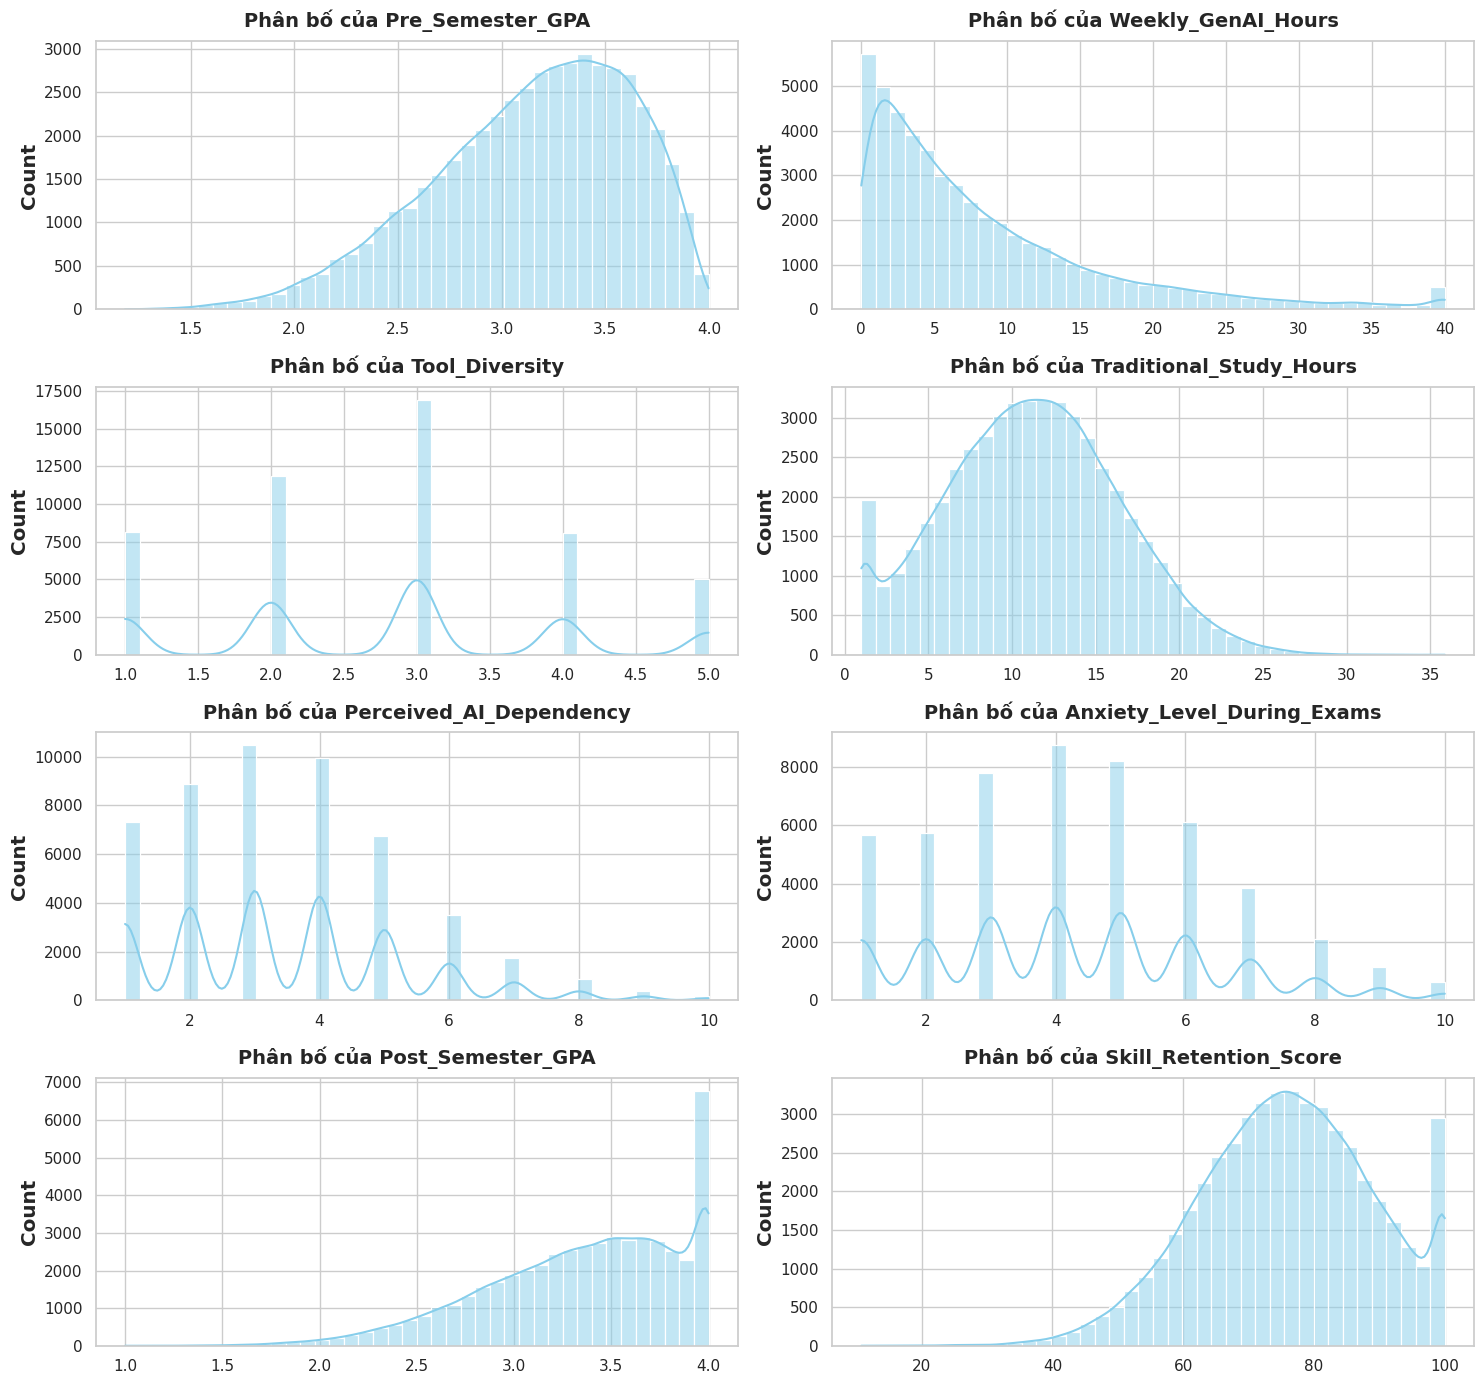

In [ ]:
# Biểu đồ phân phối
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=40)
    axes[i].set_title(f'Phân bố của {col}', fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre_Semester_GPA**: Lệch trái, phần lớn sinh viên có GPA cao (tập trung từ mốc 3.0-3.5).

- **Weekly_GenAI_Hours**: Lệch phải nặng, phần lớn sinh viên dùng AI rất ít (<5 tiếng/tuần). Tuy nhiên có một nhóm nhỏ lạm dụng AI khoảng 40 tiếng/tuần (có mốc gồ lên ở mức 40).

- **Tool_Diversity**: Đạt đỉnh ở mốc 3, đa số sinh viên dùng khoảng 3 công cụ.

- **Traditional_Study_Hours:** Phân bố khá đối xứng, đạt đỉnh ở khoảng 11-12 tiếng. Tuy nhiên ở mốc đầu (<3 tiếng) lại vọt lên cao bất thường (có thể là những sinh viên dùng AI nhiều hoặc lười học).

- **Perceived_AI_Dependency:** Có độ lệnh phải nhẹ. Phần lớn mức độ phụ thuộc của sinh viên ở mức nhẹ (2-4), ít người phụ thuộc nặng (>8).

- **Anxiety_Level_During_Exams:** Có độ lệch phải nhẹ. Phần lớn mức độ lo lắng của sinh viên ở mức nhẹ (2-5), ít người lo lắng cực đoan (>8).

- **Post_Semester_GPA: Lệch trái**. Phần lớn sinh viên có GPA sau học kỳ ở mức cao (từ 3.0 trở lên). Đặc biệt ở mốc 4.0 vọt lên cao bất thường so với Pre_Semester_GPA (có thể việc dùng AI đã buff điểm cao lên vọt).

- **Skill_Retention_Score:** Đa số sinh viên giữ được kỹ năng ở mức khá cao (70-80). Tuy nhiên mốc 100 lại cao vọt lên bất thường y hệt trường hợp của GPA đều cao ở mốc cuối, có thể việc dùng AI đã buff điểm cao lên vọt.


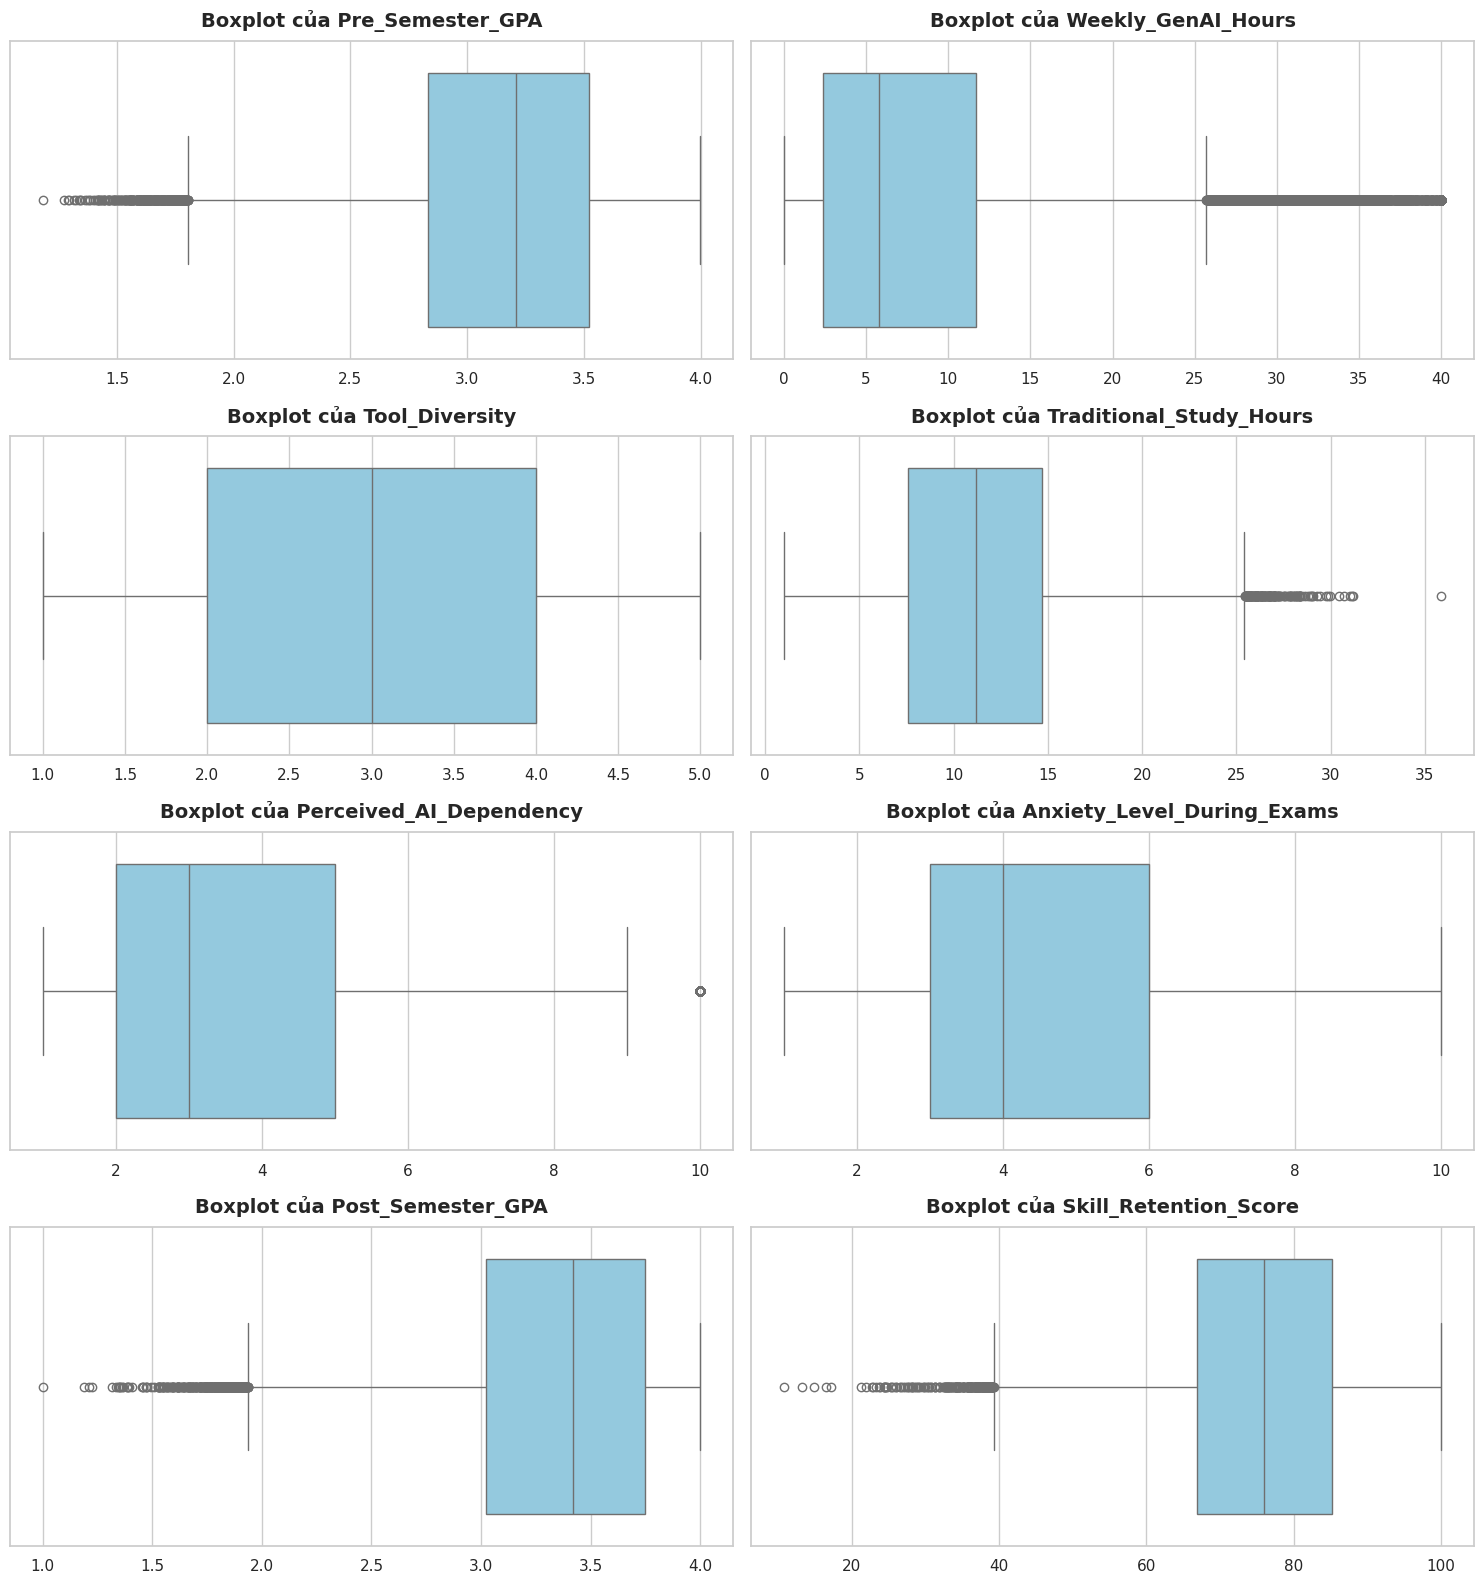

In [ ]:
# Boxplot
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x = df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot của {col}', fontweight="bold")
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre_Semester_GPA, Post_Semester_GPA, Skill_Retention_Score** đều có dải ngoại lai kéo dài hẳn về phía bên trái. Cho thấy dù phần lớn sinh viên học khá giỏi vẫn có một nhóm nhỏ bị tụt lại phía sau rất xa.

- **Weekly_GenAI_Hours** xuất hiện một dải ngoại lai rất dài ở phía bên phải từ mốc 25-40h/tuần. Đây là nhóm người lạm dụng AI vượt mức bình thường kéo theo một điểm ngoại lai tại mốc 10 ở biến Perceived_AI_Dependency.

- **Traditional_Study_Hours** có ngoại lai kéo dài về phía bên phải (25-35h/tuần). Đây là nhóm người có thời gian tự học bằng pp truyền thống vượt so với phần đông sinh viên còn lại.

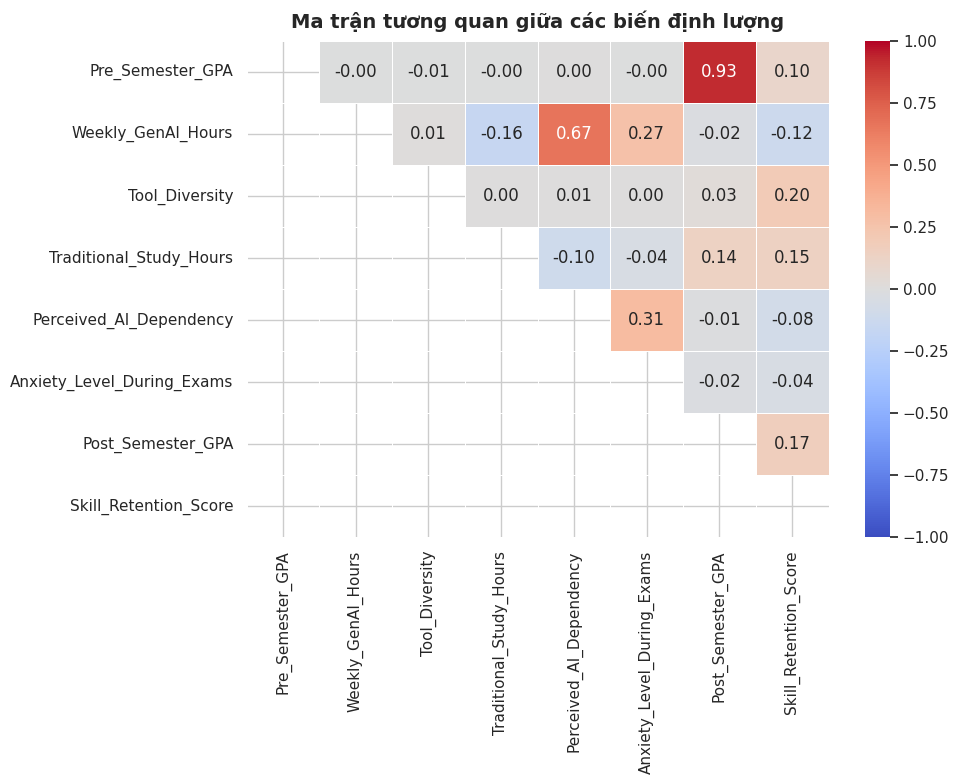

In [ ]:
# Ma trận tương quan
corr_matrix = df[numerical_cols].corr()
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.6, vmin=-1, vmax=1)

plt.title('Ma trận tương quan giữa các biến định lượng', fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét**
- **Pre_Semester_GPA và Post_Semester_GPA** có hệ số tương quan lên tới 0.93, nếu đưa cả hai vào các mô hình tuyến tính sẽ bị nhiễu trọng số. Nên cân nhắc chỉ giữ lại một biến hoặc tạo ra biến mới bằng cách kết hợp 2 biến này lại

- **Weekly_GenAI_Hours và Perceived_AI_Dependency** có tương quan khá mạnh với nhau (0.67). Đồng thời sự phụ thuộc này lại tương quan dương với Anxiety_Level_During_Exams (0.31). Khi sinh viên giành nhiều thời gian cho AI thì mức độ phụ thuộc càng cao và tâm lý lo lắng khi vào phòng thi cũng tăng lên do lúc đấy ko được dùng AI.


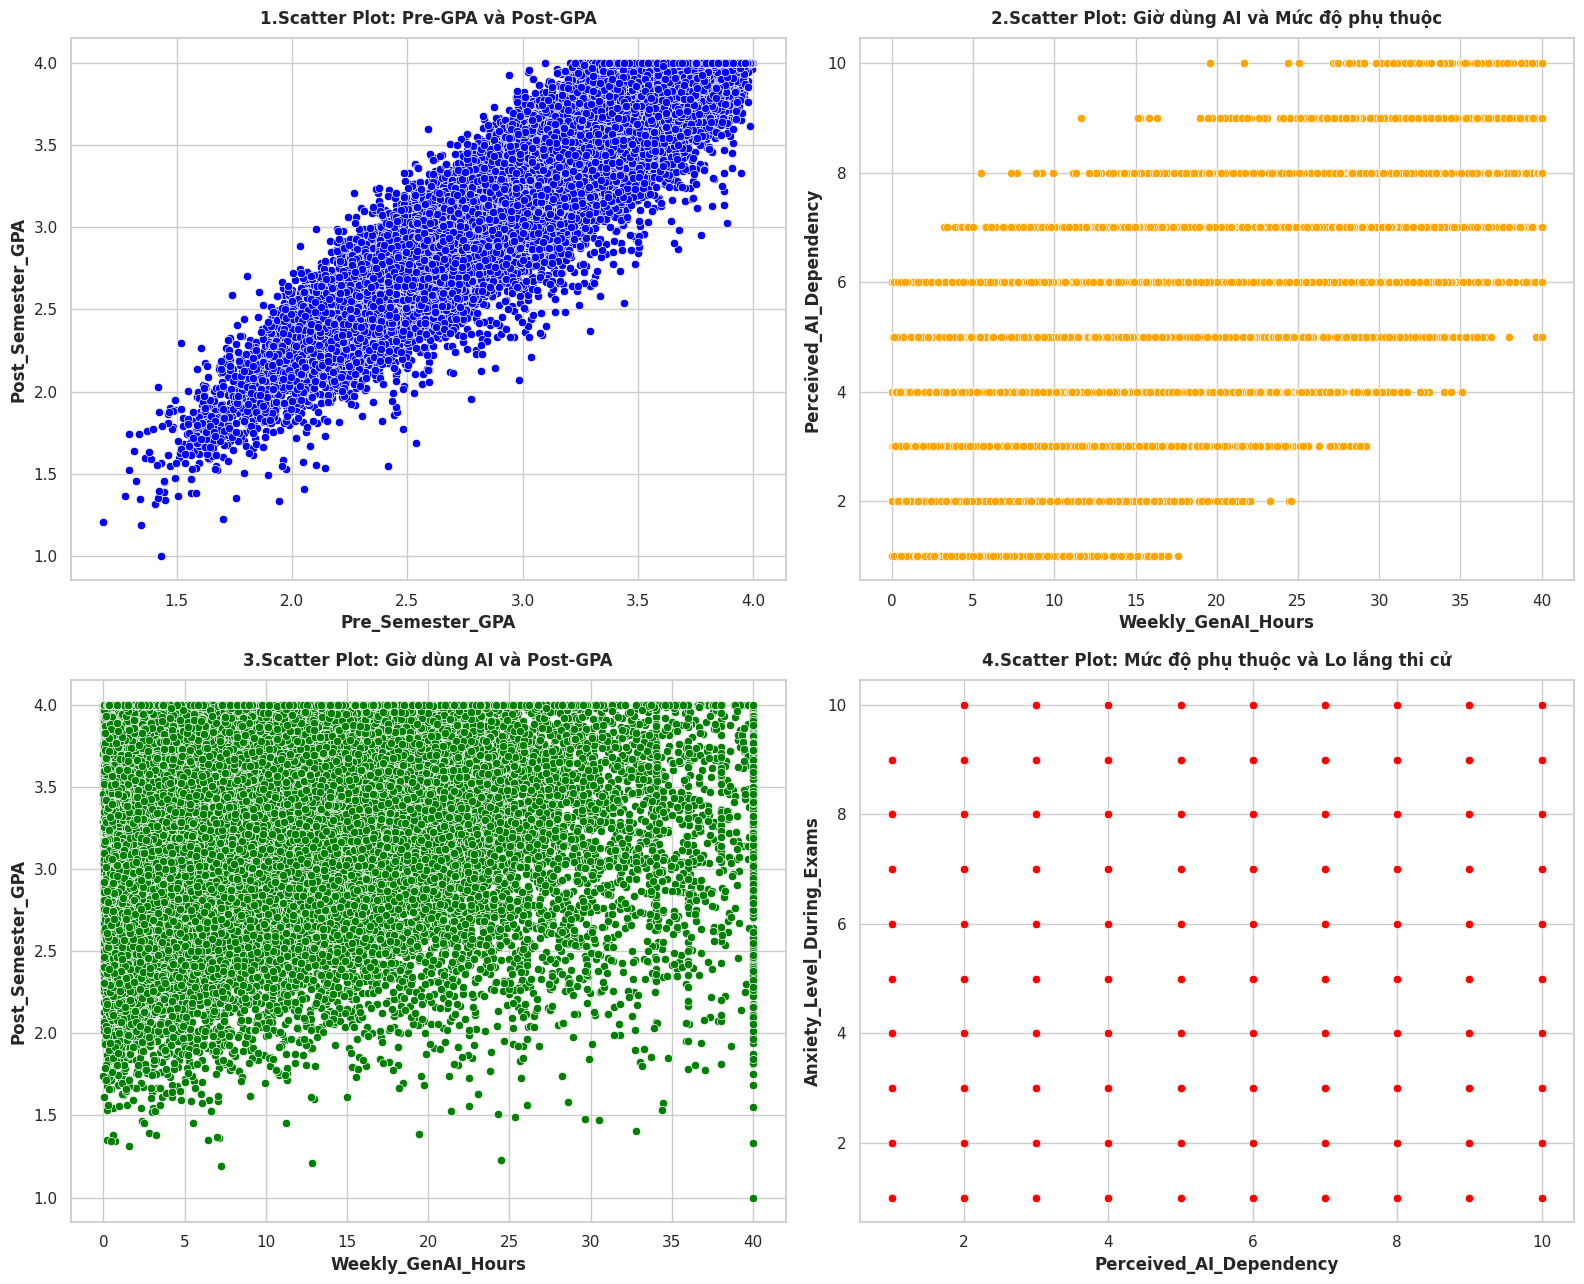

In [ ]:
# Scatter plot

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Pre_Semester_GPA và Post_Semester_GPA
sns.scatterplot(x='Pre_Semester_GPA', y='Post_Semester_GPA', data=df, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('1.Scatter Plot: Pre-GPA và Post-GPA', fontsize=12, weight='bold')

# Weekly_GenAI_Hours và Perceived_AI_Dependency
sns.scatterplot(x='Weekly_GenAI_Hours', y='Perceived_AI_Dependency', data=df, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('2.Scatter Plot: Giờ dùng AI và Mức độ phụ thuộc', fontsize=12, weight='bold')

# Weekly_GenAI_Hours và Post_Semester_GPA
sns.scatterplot(x='Weekly_GenAI_Hours', y='Post_Semester_GPA', data=df, ax=axes[1, 0], color='green')
axes[1, 0].set_title('3.Scatter Plot: Giờ dùng AI và Post-GPA', fontsize=12, weight='bold')

# Perceived_AI_Dependency và Anxiety_Level_During_Exams
sns.scatterplot(x='Perceived_AI_Dependency', y='Anxiety_Level_During_Exams', data=df, ax=axes[1, 1], color='red')
axes[1, 1].set_title('4.Scatter Plot: Mức độ phụ thuộc và Lo lắng thi cử', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Pre-GPA và Post-GPA**: Các chấm tạo dải dốc lên rõ rệt. Tuyến tính thuận cực mạnh (0.93), minh chứng cho hiện tượng đa cộng tuyến.
- **Giờ dùng AI và Mức độ phụ thuộc**: Mật độ chấm dịch dần lên các bậc thang cao hơn. Tuyến tính thuận (0.67), dùng nhiều nên bị lệ thuộc.
- **Giờ dùng AI và Post-GPA**: Phi tuyến tính (-0.02).
- **Mức độ phụ thuộc và Lo lắng thi cử**: Tuyến tính thuận mức vừa (0.31), lệ thuộc AI cao làm tăng áp lực phòng thi.

## Categorical Features (Thanh Hoàng)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu (object, category, bool).
  - Kiểm tra số lượng giá trị duy nhất (Cardinality - nunique). Lưu ý đặc biệt: Nếu một biến định tính có quá nhiều nhóm (ví dụ >50 nhóm), cần cảnh báo vì sẽ khó mã hóa sau này.

  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) và đề xuất hướng xử lý (điền bằng nhóm xuất hiện nhiều nhất - Mode, hoặc tạo một nhóm mới tên là "Unknown").

- Thống kê mô tả & Tần suất:
  - Lập bảng tần suất (Count) và tần suất phần trăm (Percentage) cho từng danh mục.
  - Trực quan hóa bằng biểu đồ cột (Bar chart) hoặc biểu đồ tròn (Pie chart - chỉ dùng khi có ít hơn 5 danh mục) để xem có sự mất cân bằng giữa các nhóm hay không.

- Mối tương quan:
  - Sử dụng Crosstab để xem tần suất kết hợp giữa các biến định tính quan trọng với nhau.

In [ ]:
categorical_data=df.select_dtypes(include=['object','bool'])
categorical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Major_Category            50000 non-null  object
 1   Year_of_Study             50000 non-null  object
 2   Primary_Use_Case          50000 non-null  object
 3   Prompt_Engineering_Skill  50000 non-null  object
 4   Paid_Subscription         50000 non-null  bool  
 5   Institutional_Policy      50000 non-null  object
 6   Burnout_Risk_Level        50000 non-null  object
dtypes: bool(1), object(6)
memory usage: 2.7+ MB


In [ ]:
categorical_data.nunique()

,0
Major_Category,5
Year_of_Study,5
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Paid_Subscription,2
Institutional_Policy,3
Burnout_Risk_Level,3


In [ ]:
categorical_data.isnull().sum()

,0
Major_Category,0
Year_of_Study,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Paid_Subscription,0
Institutional_Policy,0
Burnout_Risk_Level,0


### Cấu trúc dữ liệu & Kiểm tra đặc trưng

Qua phân tích tập dữ liệu `ai_student_impact_dataset.csv`, nhóm ghi nhận có tổng cộng 7 biến phân loại phản ánh hành vi, môi trường và tác động của AI đối với sinh viên.

| Biến định tính | Mô tả ý nghĩa | Kiểu dữ liệu | Số nhóm (Cardinality) | Missing |
| :--- | :--- | :---: | :---: | :---: |
| **Major_Category** | Khối ngành học thuật | object | 5 | 0 |
| **Year_of_Study** | Năm học của sinh viên | object | 5 | 0 |
| **Primary_Use_Case** | Mục đích sử dụng AI chính | object | 5 | 0 |
| **Prompt_Engineering_Skill** | Kỹ năng viết Prompt | object | 3 | 0 |
| **Paid_Subscription** | Có trả phí mua AI không | bool | 2 | 0 |
| **Institutional_Policy** | Quy định AI của nhà trường | object | 3 | 0 |
| **Burnout_Risk_Level** | Mức rủi ro kiệt sức tâm lý | object | 3 | 0 |

**Nhận xét:**
* **Chất lượng dữ liệu lý tưởng:** Tỷ lệ khuyết trên toàn bộ 7 biến đều là **0%**. Dữ liệu được thu thập rất sạch, không yêu cầu các kỹ thuật nội suy hay loại bỏ dòng khuyết thiếu (imputation/dropping).
* **Cardinality hoàn hảo:** Tất cả các biến đều có số nhóm <= 5. Cấu trúc này đảm bảo khi áp dụng kỹ thuật *One-Hot Encoding* ở bước chuẩn bị dữ liệu, số chiều của không gian ma trận mới sinh ra sẽ rất thấp (chỉ khoảng 26 cột bổ sung), tuyệt đối không gây ra hiện tượng bùng nổ số chiều (Curse of Dimensionality) làm ảnh hưởng tới thuật toán Machine Learning.

In [ ]:
cat_cols = categorical_data.columns.tolist()


 ==== Bảng tần suất của Major_Category ====
                Count  Percentage (%)
Major_Category                       
STEM            15059           30.12
Business        12538           25.08
Humanities       9994           19.99
Medical          6476           12.95
Arts             5933           11.87


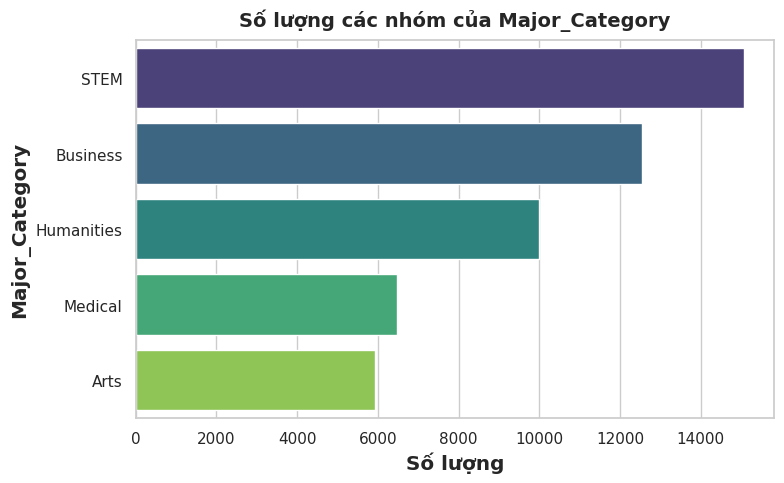


 ==== Bảng tần suất của Year_of_Study ====
               Count  Percentage (%)
Year_of_Study                       
Junior         11045           22.09
Freshman       11031           22.06
Senior         10634           21.27
Sophomore       9860           19.72
Graduate        7430           14.86


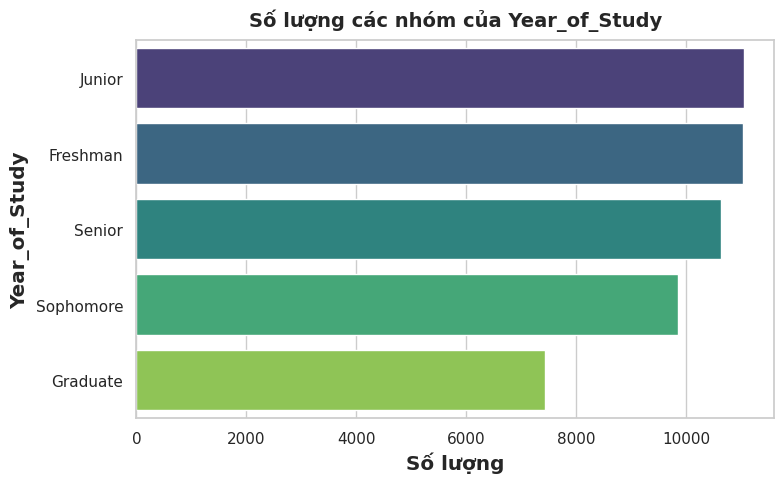


 ==== Bảng tần suất của Primary_Use_Case ====
                           Count  Percentage (%)
Primary_Use_Case                                
Debugging/Troubleshooting  12295           24.59
Copywriting/Drafting       12011           24.02
Ideation                   10721           21.44
Summarizing_Reading         8633           17.27
Direct_Answer_Generation    6340           12.68


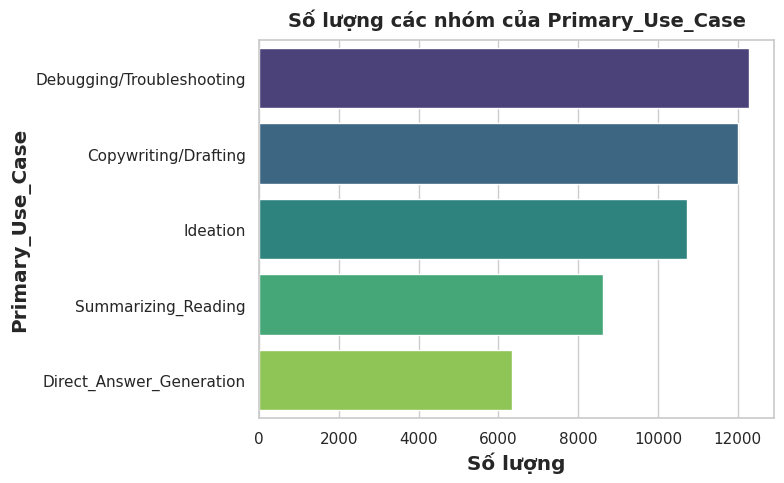


 ==== Bảng tần suất của Prompt_Engineering_Skill ====
                          Count  Percentage (%)
Prompt_Engineering_Skill                       
Beginner                  18495           36.99
Intermediate              17696           35.39
Advanced                  13809           27.62


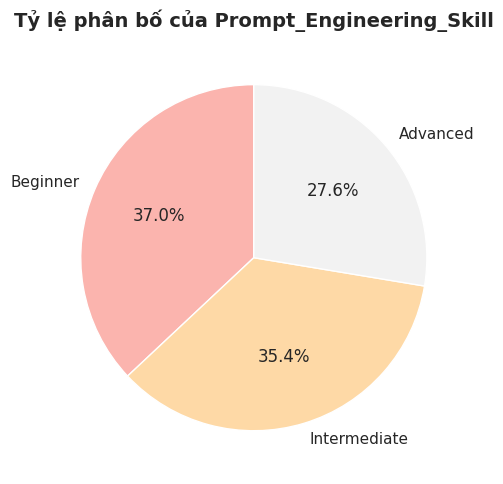


 ==== Bảng tần suất của Paid_Subscription ====
                   Count  Percentage (%)
Paid_Subscription                       
False              28846           57.69
True               21154           42.31


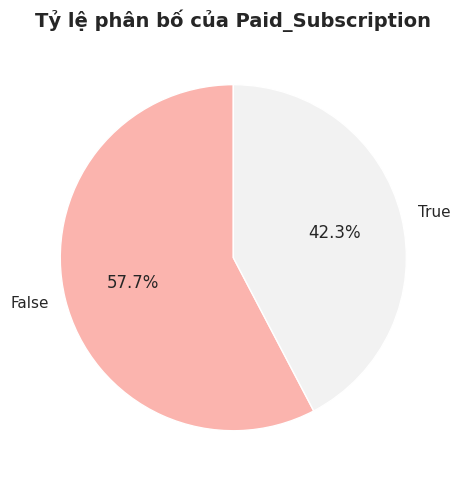


 ==== Bảng tần suất của Institutional_Policy ====
                       Count  Percentage (%)
Institutional_Policy                        
Allowed_With_Citation  25224           50.45
Actively_Encouraged    14988           29.98
Strict_Ban              9788           19.58


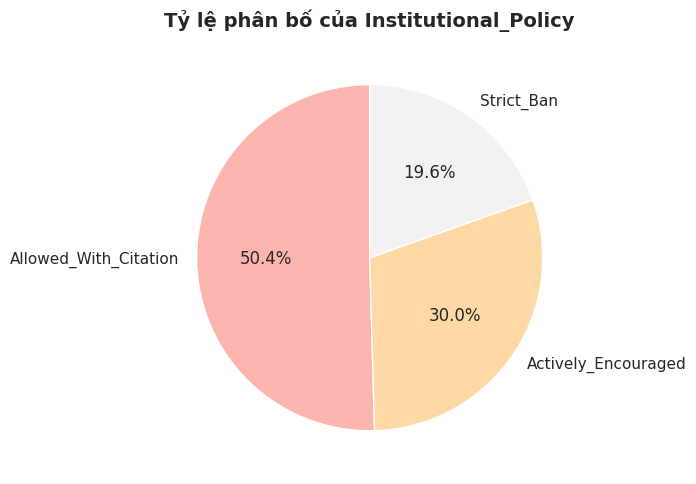


 ==== Bảng tần suất của Burnout_Risk_Level ====
                    Count  Percentage (%)
Burnout_Risk_Level                       
Medium              21144           42.29
Low                 16369           32.74
High                12487           24.97


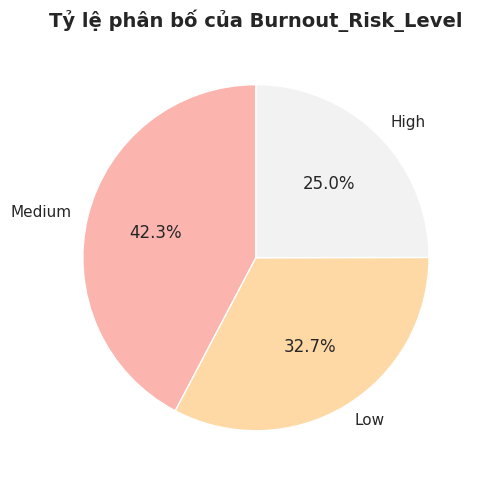

In [ ]:
for col in cat_cols :
    print(f"\n ==== Bảng tần suất của {col} ====")
    freq_table = pd.DataFrame({
        'Count': categorical_data[col].value_counts(dropna=False),
        'Percentage (%)': (categorical_data[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    })
    print(freq_table)

    plt.figure(figsize=(8, 5))

    if categorical_data[col].nunique() < 5:
        categorical_data[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', ylabel='')
        plt.title(f"Tỷ lệ phân bố của {col}")
    elif categorical_data[col].nunique() >= 5:
        sns.countplot(y=col, data=categorical_data, order=categorical_data[col].value_counts().index, palette='viridis')
        plt.title(f"Số lượng các nhóm của {col}")
        plt.xlabel("Số lượng")
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

============ CROSSTAB 1: NGÀNH HỌC & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level   Low  Medium  High
Major_Category                        
Arts                2014    2573  1346
Business            4193    5294  3051
Humanities          3606    4315  2073
Medical             2243    2733  1500
STEM                4313    6229  4517


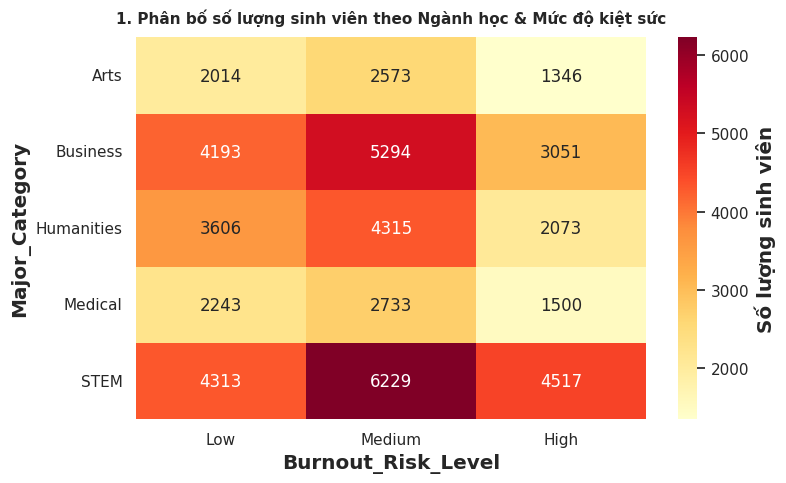

In [ ]:
print("============ CROSSTAB 1: NGÀNH HỌC & MỨC ĐỘ KIỆT SỨC ============")
count_major_by_burnout = pd.crosstab(
    index=df['Major_Category'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_major_by_burnout)

plt.figure(figsize=(8, 5))
sns.heatmap(count_major_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.title('1. Phân bố số lượng sinh viên theo Ngành học & Mức độ kiệt sức', fontsize=11, fontweight='bold')
plt.ylabel('Major_Category')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** STEM có tỷ lệ Burnout High cao nhất (30%), trong khi Arts có tỷ lệ Burnout Low cao nhất (33.9%). Ngành học ảnh hưởng đến stress của sinh viên.

============ CROSSTAB 2: KỸ NĂNG PROMPT & MỤC ĐÍCH SỬ DỤNG AI ============

 Bảng tần suất số lượng sinh viên:
Prompt_Engineering_Skill   Beginner  Intermediate  Advanced
Primary_Use_Case                                           
Copywriting/Drafting           4658          4214      3139
Debugging/Troubleshooting      4128          4391      3776
Direct_Answer_Generation       2376          2213      1751
Ideation                       4121          3793      2807
Summarizing_Reading            3212          3085      2336


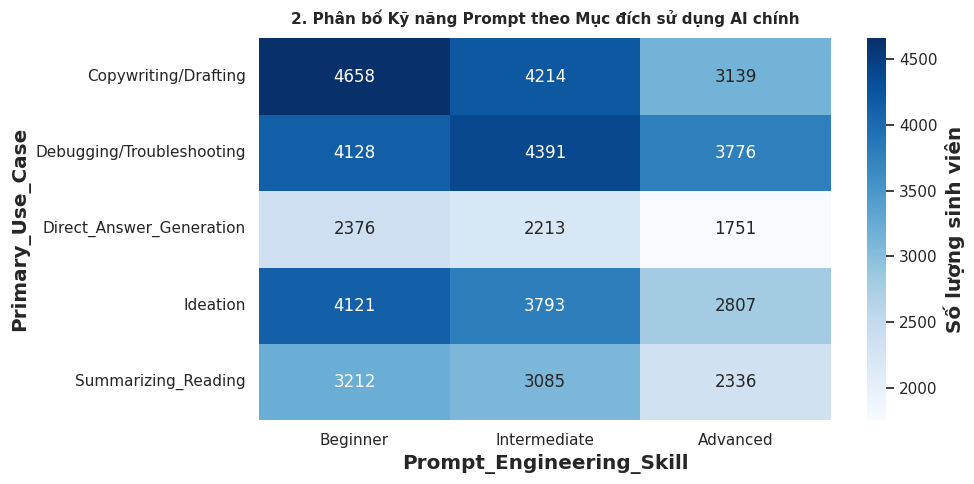

In [ ]:
print("============ CROSSTAB 2: KỸ NĂNG PROMPT & MỤC ĐÍCH SỬ DỤNG AI ============")
count_skill_by_usecase = pd.crosstab(
    index=df['Primary_Use_Case'],
    columns=df['Prompt_Engineering_Skill']
)[['Beginner', 'Intermediate', 'Advanced']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_skill_by_usecase)

plt.figure(figsize=(10, 5))
sns.heatmap(count_skill_by_usecase, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.title('2. Phân bố Kỹ năng Prompt theo Mục đích sử dụng AI chính', fontsize=11, fontweight='bold')
plt.ylabel('Primary_Use_Case')
plt.xlabel('Prompt_Engineering_Skill')
plt.tight_layout()
plt.show()

**💡 Insight:** Skill Level quyết định Mục Đích: Sinh viên skill khác nhau dùng AI cho mục đích khác nhau. Advanced = chuyên (Debugging), Beginner = generalist (dùng tất cả).

============ CROSSTAB 3: TRẢ PHÍ AI & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level    Low  Medium  High
Paid_Subscription                      
False               10266   12491  6089
True                 6103    8653  6398


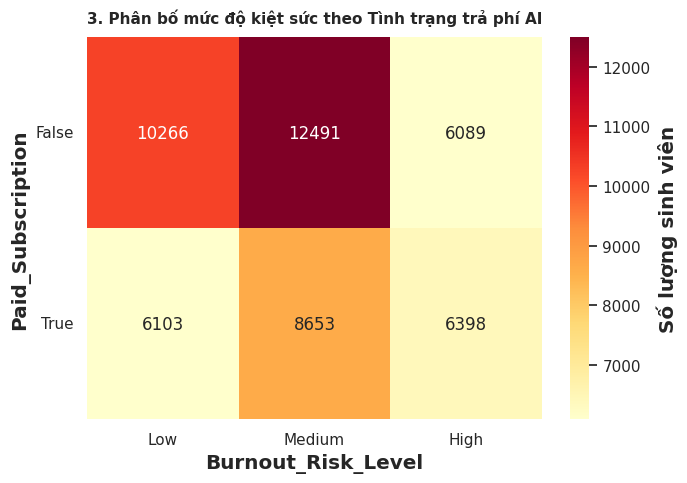

In [ ]:
print("============ CROSSTAB 3: TRẢ PHÍ AI & MỨC ĐỘ KIỆT SỨC ============")
count_paid_by_burnout = pd.crosstab(
    index=df['Paid_Subscription'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_paid_by_burnout)

plt.figure(figsize=(7, 5))
sns.heatmap(count_paid_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})

plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('3. Phân bố mức độ kiệt sức theo Tình trạng trả phí AI', fontsize=11, fontweight='bold')
plt.ylabel('Paid_Subscription')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** Sinh viên có **Paid_Subscription = Yes** có tỷ lệ Burnout High cao hơn (30.2% vs 21.1%). Điều này gợi ý sinh viên stress hơn có thể sẵn sàng chi tiền cho AI tools để "cứu" họ khỏi workload quá tải.

============ CROSSTAB 4: QUY ĐỊNH TRƯỜNG & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level      Low  Medium  High
Institutional_Policy                     
Actively_Encouraged    5079    6346  3563
Allowed_With_Citation  8320   10893  6011
Strict_Ban             2970    3905  2913


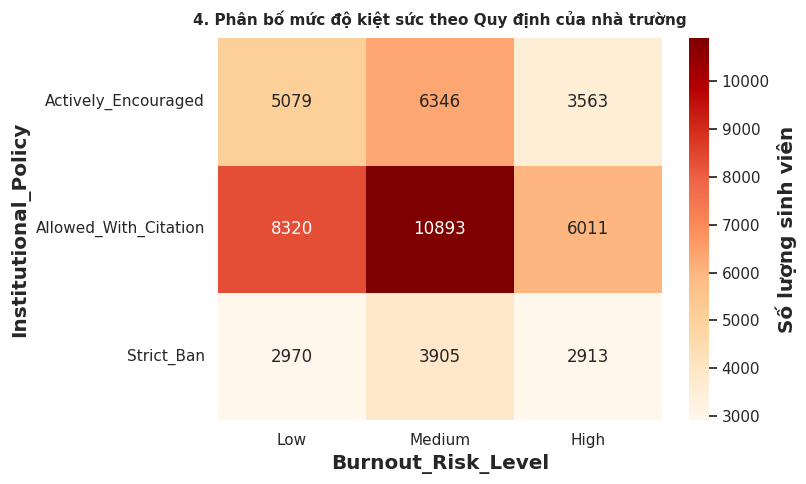

In [ ]:
print("============ CROSSTAB 4: QUY ĐỊNH TRƯỜNG & MỨC ĐỘ KIỆT SỨC ============")
count_policy_by_burnout = pd.crosstab(
    index=df['Institutional_Policy'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_policy_by_burnout)

plt.figure(figsize=(8, 5))
sns.heatmap(count_policy_by_burnout, annot=True, fmt='d', cmap='OrRd', cbar_kws={'label': 'Số lượng sinh viên'})

plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('4. Phân bố mức độ kiệt sức theo Quy định của nhà trường', fontsize=11, fontweight='bold')
plt.ylabel('Institutional_Policy')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** Sinh viên ở nơi Allowed_with_Citaation có tỷ lệ Burnout High cao nhất, trong khi hai policy khác (Ban & Allowed) có tỷ lệ gần nhau (23.8%).
Điều này gợi ý: Giới hạn quyền sử dụng AI có thể gây stress/burnout cao hơn.

============ CROSSTAB 5: MỤC ĐÍCH SỬ DỤNG AI & MỨC ĐỘ KIỆT SỨC ============

📊 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level          Low  Medium  High
Primary_Use_Case                             
Copywriting/Drafting       4076    5174  2761
Debugging/Troubleshooting  3822    5119  3354
Direct_Answer_Generation   2021    2632  1687
Ideation                   3542    4568  2611
Summarizing_Reading        2908    3651  2074


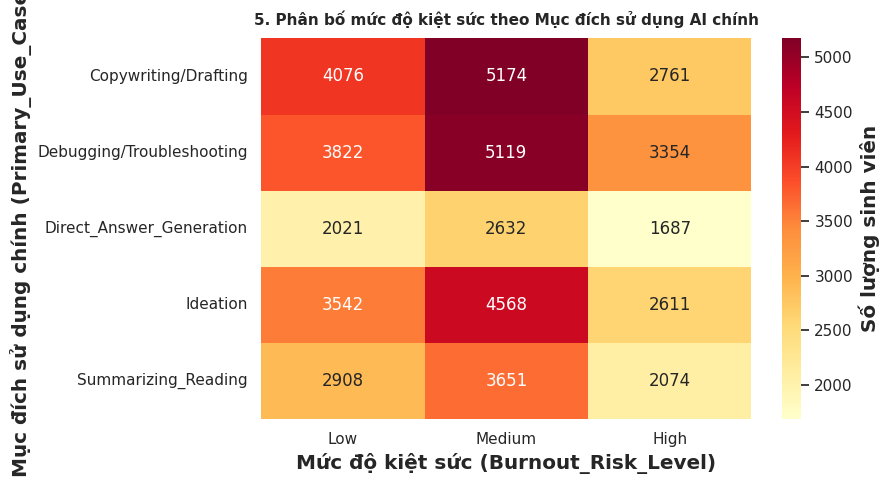

In [ ]:
print("============ CROSSTAB 5: MỤC ĐÍCH SỬ DỤNG AI & MỨC ĐỘ KIỆT SỨC ============")
count_usecase_by_burnout = pd.crosstab(
    index=df['Primary_Use_Case'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n📊 Bảng tần suất số lượng sinh viên:")
print(count_usecase_by_burnout)

plt.figure(figsize=(9, 5))
sns.heatmap(count_usecase_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('5. Phân bố mức độ kiệt sức theo Mục đích sử dụng AI chính', fontsize=11, fontweight='bold')
plt.ylabel('Mục đích sử dụng chính (Primary_Use_Case)')
plt.xlabel('Mức độ kiệt sức (Burnout_Risk_Level)')
plt.tight_layout()
plt.show()

**💡 Insight:** Số liệu thực tế phản ánh xu hướng sử dụng công cụ GenAI của sinh viên tập trung mạnh vào các tác vụ phức tạp như sửa lỗi/lập trình (*Debugging*) và viết lách (*Copywriting*). Việc các tác vụ này chiếm tỷ trọng kiệt sức cao vượt trội cho thấy tính chất công việc đòi hỏi tư duy kéo dài, kết hợp với việc phụ thuộc vào AI có khả năng đẩy sinh viên vào trạng thái quá tải tâm lý cao hơn đáng kể so với việc chỉ dùng AI để ăn sẵn câu trả lời nhanh (*Direct_Answer_Generation*). Đây là đặc trưng phân hóa bối cảnh cực kỳ chính xác để mô hình học máy gán trọng số rủi ro.



## Correlation Analysis (Minh Hoàng)

Yêu cầu:
- Kiểm tra dữ liệu:
  - Kiểm tra phân phối của biến mục tiêu. Nếu bị lệch quá nhiều (Skewed), cần đề xuất các phương pháp biến đổi (như Log Transformation) để chuẩn hóa dữ liệu.

- Phân tích Đa biến :
  - Dùng điểm tương hỗ MI (Mutual Information) để lọc ra các biến quan trọng với biến mục tiêu. Từ đó, xem xét các mối quan hệ xoay quanh những biến có điểm MI cao.
  - Biến mục tiêu và các biến định lượng: Vẽ biểu đồ Boxplot hoặc Violin Plot của biến định lượng theo từng nhóm của Target (nếu Target là định tính), hoặc vẽ Scatter Plot (nếu cả hai là định lượng) để xem biến định lượng nào tác động mạnh đến Target.

  - Biến mục tiêu và biến dịnh tính: Vẽ biểu đồ cột chồng hoặc biểu đồ tỉ lệ để xem tỷ lệ phân bố của Target thay đổi như thế nào trên từng danh mục.

In [ ]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


Original Skewness: -0.675
Square Transformation Skewness: -0.347
Cube Transformation Skewness: -0.090


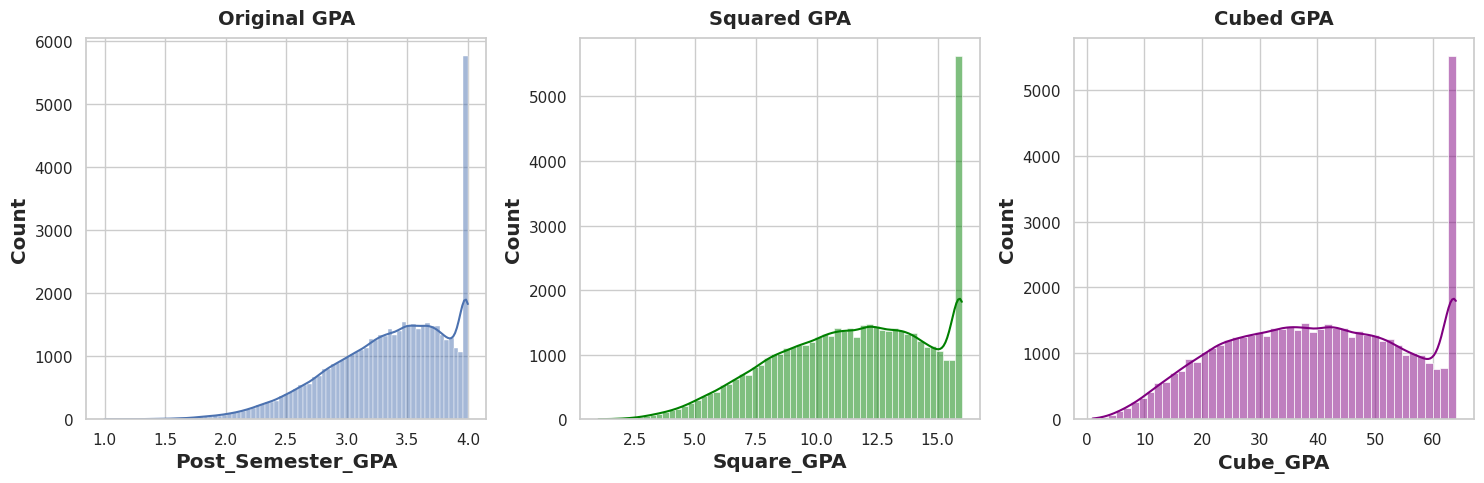

In [ ]:

target = 'Post_Semester_GPA'

# Phép biến đổi Bình phương (Square Transformation)
df['Square_GPA'] = df[target] ** 2

# Phép biến đổi Lập phương (Cube Transformation)
df['Cube_GPA'] = df[target] ** 3

# Kiểm tra lại độ lệch (Skewness)
print(f"Original Skewness: {df[target].skew():.3f}")
print(f"Square Transformation Skewness: {df['Square_GPA'].skew():.3f}")
print(f"Cube Transformation Skewness: {df['Cube_GPA'].skew():.3f}")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title('Original GPA')

sns.histplot(df['Square_GPA'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Squared GPA')

sns.histplot(df['Cube_GPA'], kde=True, ax=axes[2], color='purple')
axes[2].set_title('Cubed GPA')

plt.tight_layout()
plt.show()

Đánh giá phân phối dữ liệu gốc:
- Độ lệch (Skewness): -0.675  

->Biến Post_Semester_GPA bị lệch trái (Left-skewed / Negative Skewness) ở mức độ vừa phải.

Không nên sử dụng Log Transformation vì biến GPA của chúng ta đang lệch trái, việc áp dụng phép biến đổi Log làm dữ liệu bị lệch nặng hơn (Skewness giảm xuống còn -0.99).

Đề xuất các phương pháp chuẩn hóa phù hợp:
- Phép biến đổi lũy thừa (Square / Cube Transformation):
- Bình phương ($x^2$) hoặc lập phương ($x^3$) các giá trị GPA. Việc này sẽ kéo giãn sự khác biệt ở các giá trị lớn và thu hẹp sự khác biệt ở các giá trị nhỏ, giúp phân phối cân xứng hơn.=> đã làm minh họa ở trên
- Không biến đổi (Giữ nguyên dữ liệu gốc):
- Với mức skewness là -0.675, đây là mức độ lệch nằm trong ngưỡng cho phép.
- Nếu sử dụng các thuật toán dạng cây như Random Forest, XGBoost, LightGBM, không cần thiết phải chuẩn hóa biến mục tiêu vì các mô hình này không nhạy cảm với phân phối của dữ liệu.


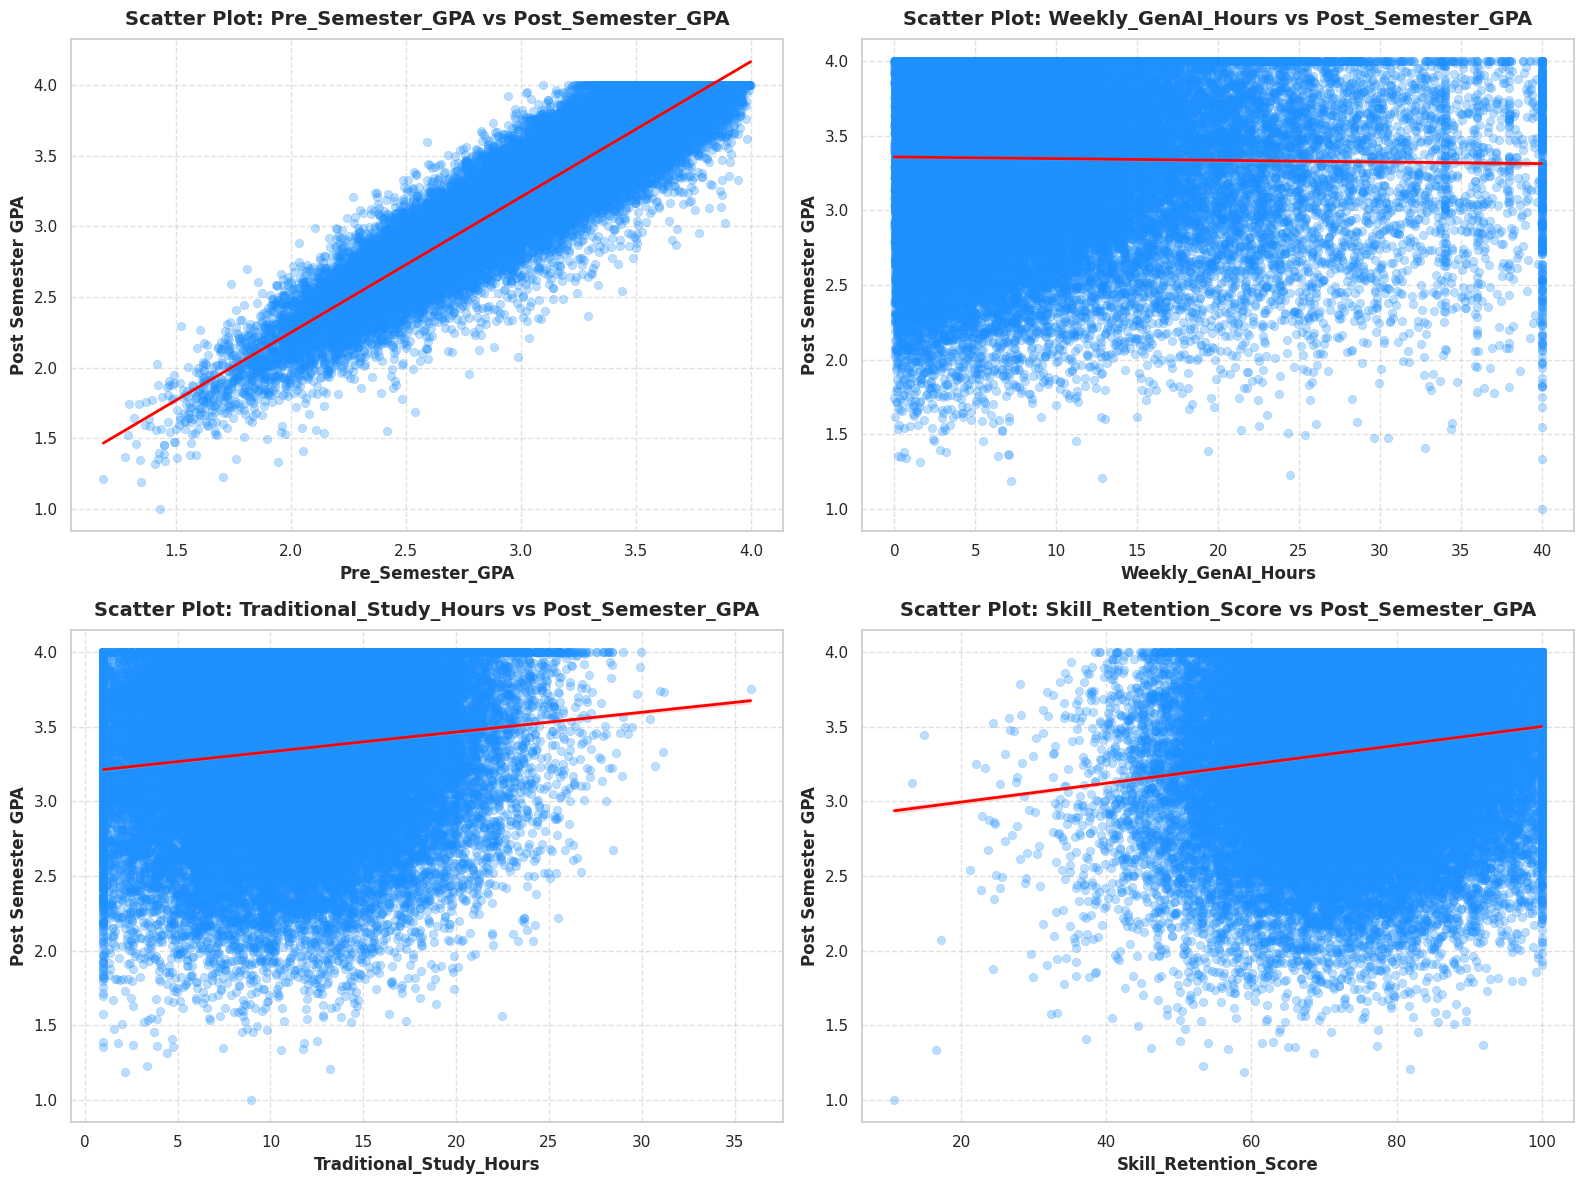

In [ ]:
quant_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(quant_cols):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        alpha=0.3,
        color='dodgerblue',
        edgecolor=None
    )

    sns.regplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        scatter=False,
        color='red',
        line_kws={"linewidth": 2}
    )

    axes[i].set_title(f'Scatter Plot: {col} vs {target}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Post Semester GPA', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

- Pre_Semester_GPA (Tương quan Tuyến tính Mạnh): Đường hồi quy màu đỏ có độ dốc lớn. Sự tương quan thuận là cực kỳ mạnh mẽ.
- Skill_Retention_Score (Tương quan Thuận Nhẹ): Đường xu hướng dốc lên một góc nhỏ. Có xu hướng những người có điểm duy trì kỹ năng cao hơn thì GPA cũng nhỉnh hơn.
- Traditional_Study_Hours (Tương quan Thuận Rất Nhẹ): Đường xu hướng gần như đi ngang nhưng vẫn có độ dốc dương rất nhỏ.
- Weekly_GenAI_Hours (Không có xu hướng rõ rệt): Đường xu hướng đi ngang hoàn toàn -> Thời lượng dùng AI hàng tuần hiện không cho thấy mối liên hệ trực tiếp với việc điểm số tăng hay giảm.

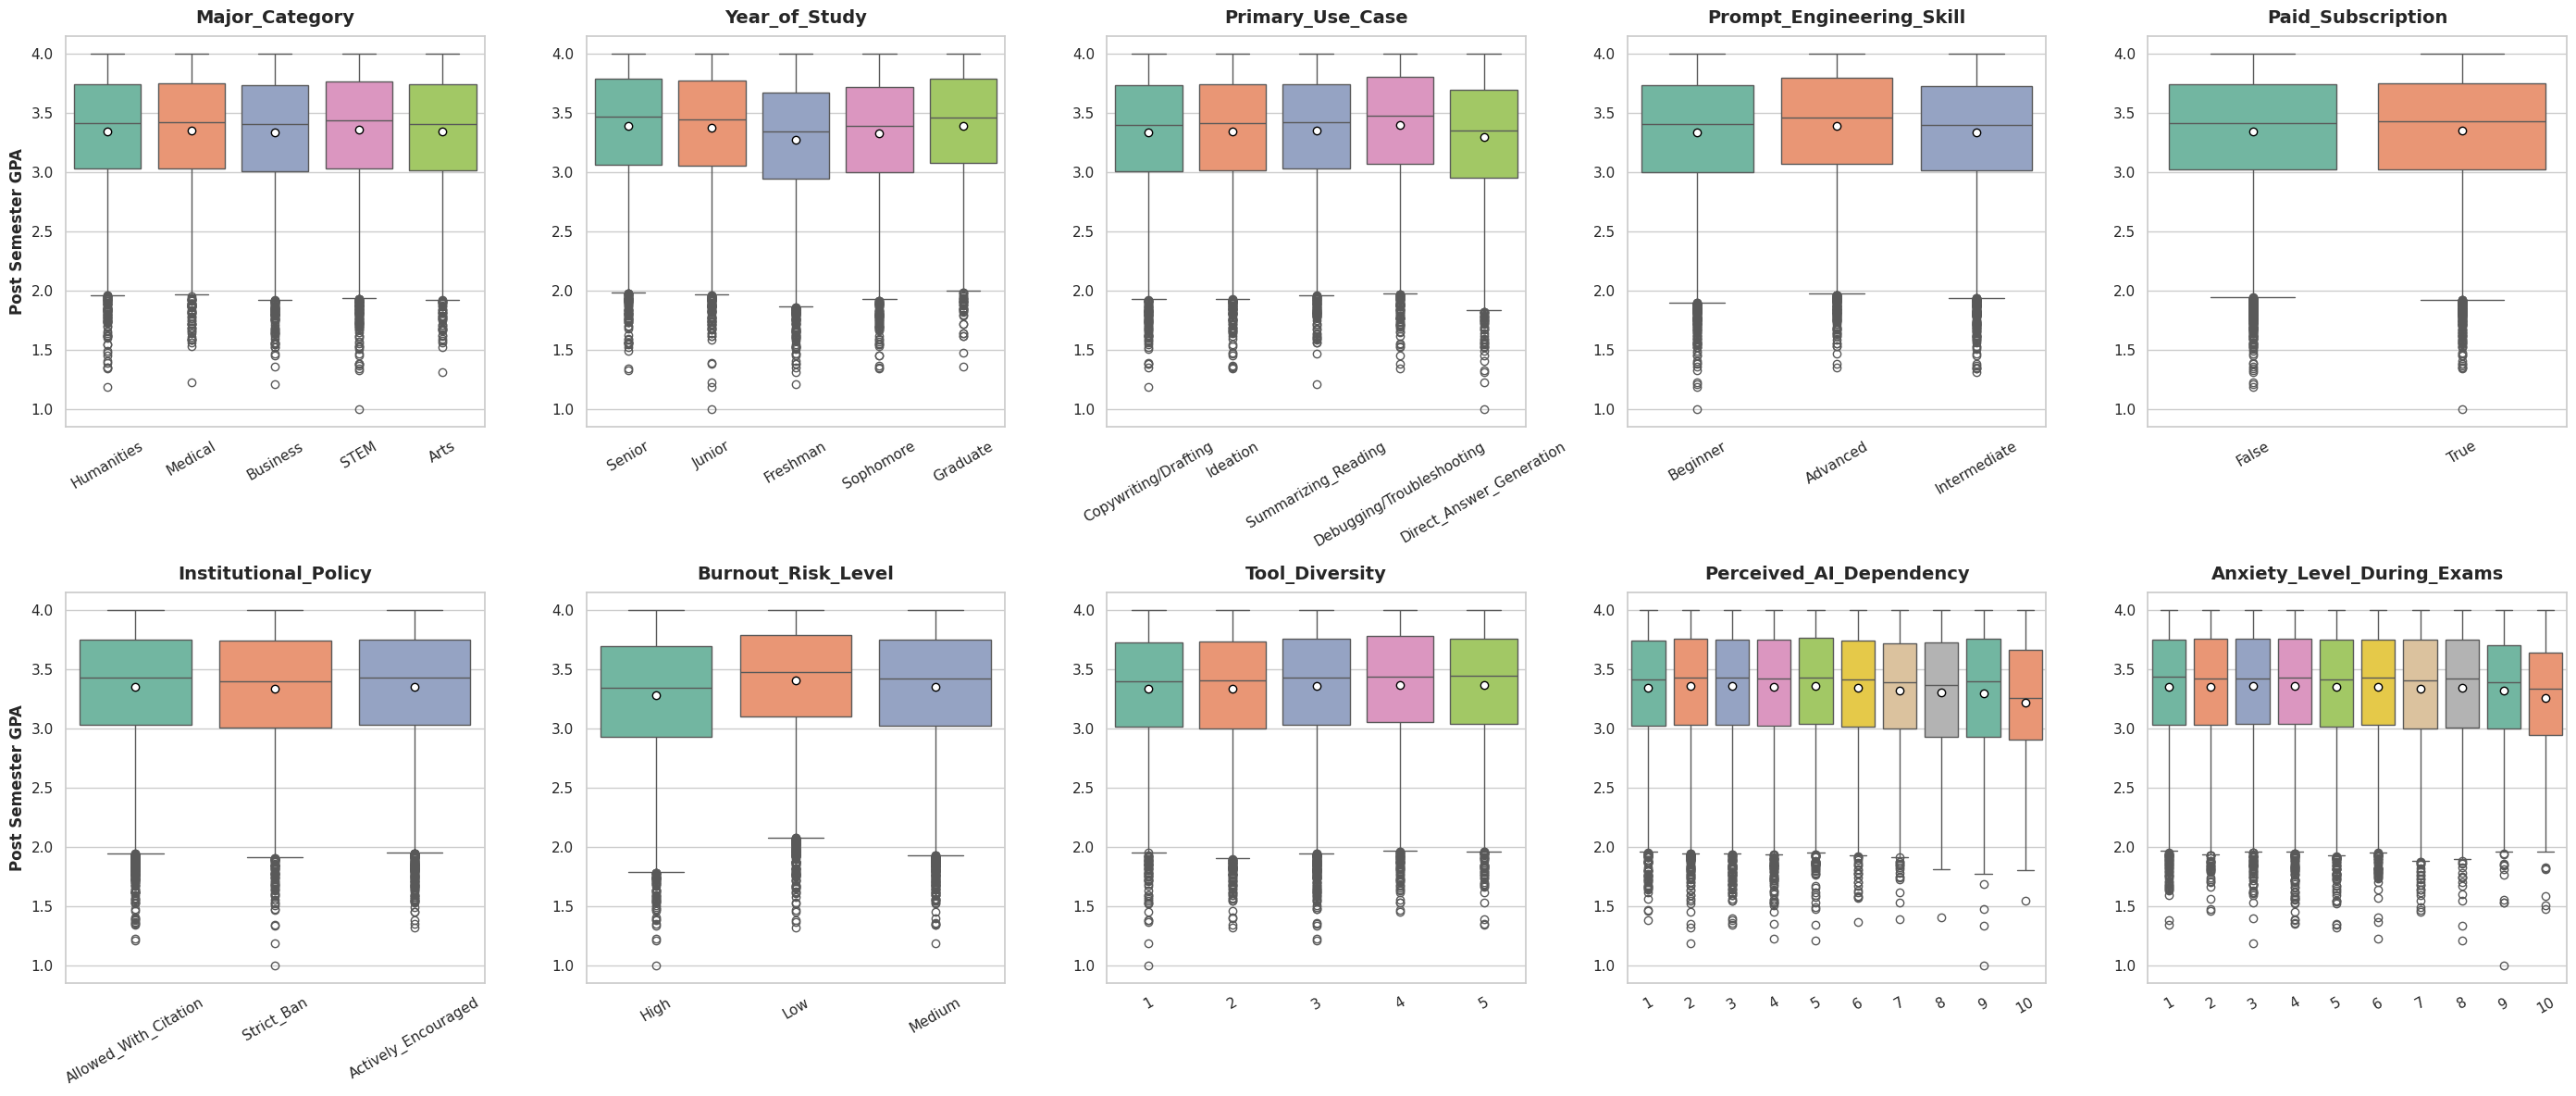

In [ ]:

# Tổng hợp tất cả biến định tính
# Bao gồm biến chữ/boolean
cat_cols_strict = df.select_dtypes(include=['object', 'bool']).columns.tolist()
# Và 3 biến số nguyên rời rạc
discrete_cols = ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
# Gom chung
all_qualitative_cols = cat_cols_strict + discrete_cols

# Tạo khung biểu đồ lưới 2 hàng x 5 cột (đủ cho 10 biến)
fig, axes = plt.subplots(2, 5, figsize=(28, 12))
axes = axes.flatten()

for i, col in enumerate(all_qualitative_cols):
    sns.boxplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        palette='Set2',
        showmeans=True, # Hiển thị thêm điểm Mean (trung bình)
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6}
    )

    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

    if i % 5 == 0:
        axes[i].set_ylabel('Post Semester GPA', fontsize=12)
    else:
        axes[i].set_ylabel('')

    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

- Sự phân bố của GPA cuối kỳ gần như ĐỒNG NHẤT ở tất cả các hạng mục của mọi biến định tính.
- Không có biến định tính nào tạo ra sự khác biệt rõ rệt về điểm số. Ví dụ, sinh viên dùng AI để "Copywriting/Drafting" (viết nháp) có phổ điểm hoàn toàn y hệt sinh viên dùng AI để "Debugging" (sửa lỗi code) hay "Ideation" (lên ý tưởng).
- Các điểm Trung bình (chấm trắng) và Trung vị (đường ngang trong hộp) của tất cả các nhóm trên cả 10 biểu đồ đều neo ở mức khoảng 3.0 - 3.2.

In [ ]:

# Dùng errors='ignore' để lệnh drop không báo lỗi nếu 'Student_ID' không tồn tại
X = df.drop(columns=['Student_ID', target, 'Square_GPA', 'Cube_GPA', 'Log_Post_Semester_GPA'], errors='ignore')
y = df[target]

#  Xử lý các biến rời rạc/định tính
discrete_cols = ['Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
all_discrete = discrete_cols + cat_cols

# Mã hóa (Label Encoding) cho biến chữ/boolean
X_encoded = X.copy()
le = LabelEncoder()
for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Tạo boolean mask (True/False)
discrete_features_mask = X_encoded.columns.isin(all_discrete)

# 3. Tính điểm MI
mi_scores = mutual_info_regression(
    X_encoded, y,
    discrete_features=discrete_features_mask,
    random_state=42
)
mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

print("TOP CÁC BIẾN QUAN TRỌNG NHẤT (MI SCORES):")
print(mi_series.head())

TOP CÁC BIẾN QUAN TRỌNG NHẤT (MI SCORES):
Pre_Semester_GPA           0.937000
Skill_Retention_Score      0.016435
Traditional_Study_Hours    0.011274
Year_of_Study              0.006637
Burnout_Risk_Level         0.004581
dtype: float64


- Pre_Semester_GPA (MI = 0.937) - Tương quan tuyến tính tuyệt đối: Sinh viên có điểm khởi đầu (đầu kỳ) thế nào thì cuối kỳ gần như giữ nguyên phong độ đó.-> AI chỉ mang tính hỗ trợ
- Cách sinh viên dung nạp kiến thức (Skill_Retention_Score và Traditional_Study_Hours) quan trọng hơn rất nhiều so với thời lượng tương tác với AI (Weekly_GenAI_Hours - vốn có điểm MI bét bảng).
- Sự nhiễu của các biến công nghệ: Hầu hết các biến liên quan đến AI (Số công cụ, Trả phí hay miễn phí, Kỹ năng Prompt) đều không có mối quan hệ trực tiếp đủ mạnh để quyết định điểm GPA cuối kỳ.

# Step 2: Data Preprocessing

Yêu cầu:
- clean: xử lý dữ liệu bị khuyết, trùng lặp, sửa lỗi định dạng và kiểu dữ liệu
- encode: mã hóa các biến phân loại
- impute: điền vào các giá trị NaN

In [ ]:
def load_data():
    # Read data
    data_dir = "/content/ai_student_impact_dataset.csv"
    df = pd.read_csv(data_dir, index_col="Student_ID")
    # Preprocessing
    df = clean(df)
    df = encode(df)
    df = impute(df)

    # Reform splits
    df = df.loc[df.index, :]
    return df

### Clean data

In [ ]:
def clean(df):
  ''' Hàm làm sạch dữ liệu'''
  ''' Dữ liệu sạch'''
  return df


### Impute data

In [ ]:
def impute(df):
  ''' Hàm thêm các giá trị khuyết'''
  ''' Dữ liệu không có giá trị khuyết'''
  return df

### Encode data

In [ ]:
categorical_data=df.select_dtypes(include=['object','bool'])
categorical_col=categorical_data.columns
categorical_col

Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='object')

In [ ]:
for col in categorical_col:
  print(f"{col}:" ,df[col].unique())

Major_Category: ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
Year_of_Study: ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
Primary_Use_Case: ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
Prompt_Engineering_Skill: ['Beginner' 'Advanced' 'Intermediate']
Paid_Subscription: [ True False]
Institutional_Policy: ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
Burnout_Risk_Level: ['High' 'Low' 'Medium']


In [ ]:
#Chuyển về kiểu biến Categorical
features_nom=['Major_Category','Primary_Use_Case']

# Biến có tính thứ tự sẽ được gán thứ tự
ordered_levels={
    "Year_of_Study": ['Senior','Junior' ,'Freshman' ,'Sophomore' ,'Graduate'],
    "Prompt_Engineering_Skill":['Beginner', 'Advanced', 'Intermediate'],
    "Paid_Subscription": ["False","True"],
    "Institutional_Policy": ['Strict_Ban','Allowed_With_Citation','Actively_Encouraged'],
    "Burnout_Risk_Level": ['Low', 'Medium', 'High'],
}

ordered_levels = {key: ["None"] + value for key, value in
                  ordered_levels.items()}

def encode(df):
    # Nominal categories
    for name in features_nom:
        df[name] = df[name].astype("category")
        # Add a None category for missing values
        if "None" not in df[name].cat.categories:
            df[name] = df[name].cat.add_categories("None")
    # Ordinal categories
    for name, levels in ordered_levels.items():
        df[name] = df[name].astype(CategoricalDtype(levels,
                                                    ordered=True))
    for name in ordered_levels.keys():
        df[name] = df[name].cat.codes # Ordinal encoding
    df = pd.get_dummies(df, columns=features_nom, prefix=features_nom, dummy_na=False) #One-hot encoding
    return df


In [ ]:
df_train=load_data()
df_train.head()

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,...,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Major_Category_None,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Primary_Use_Case_None
Student_ID,,,,,,,,,,,,,,,,,,,,,
100001,1,2.418,23.31,1,1,-1,8.13,5,2,6,...,True,False,False,False,True,False,False,False,False,False
100002,2,3.821,1.12,2,5,-1,16.65,3,2,9,...,False,True,False,False,False,False,False,True,False,False
100003,3,3.398,21.26,1,2,-1,10.35,5,1,9,...,False,False,False,False,False,False,False,False,True,False
100004,1,3.789,1.82,3,4,-1,15.23,2,2,2,...,False,False,False,False,True,False,False,False,False,False
100005,4,3.635,9.29,2,4,-1,12.55,4,2,4,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year_of_Study                               50000 non-null  int8   
 1   Pre_Semester_GPA                            50000 non-null  float64
 2   Weekly_GenAI_Hours                          50000 non-null  float64
 3   Prompt_Engineering_Skill                    50000 non-null  int8   
 4   Tool_Diversity                              50000 non-null  int64  
 5   Paid_Subscription                           50000 non-null  int8   
 6   Traditional_Study_Hours                     50000 non-null  float64
 7   Perceived_AI_Dependency                     50000 non-null  int64  
 8   Institutional_Policy                        50000 non-null  int8   
 9   Anxiety_Level_During_Exams                  50000 non-null  int64  
 10  Post_Seme

# Step 3: Modelling

## Problem 1: Post-GPA Prediction (Regression) (Hải)

Yêu cầu:
- Tự chọn các cột cần thiết, phù hợp cho bài toán
- Huấn luyện 3 mô hình và tìm tham số để tối ưu cho từng mô hình
- Đánh giá mô hình bằng các chỉ số `MAE,RMSE,R2` và nhận xét biểu đồ Residual
- Viết thêm file `report.md` để nhận xét kết quả và so sánh mô hình.

Chọn 3 mô hình là:
- Linear Regression : Dùng làm mô hình cơ sở (Baseline). Mặc dù đơn giản, nhưng nó lại có sức mạnh giải thích cực tốt (biết được biến nào làm tăng/giảm bao nhiêu điểm GPA).

- Decision Tree Regressor: Đại diện cho nhóm mô hình phi tuyến tính. Nó sẽ xem xét các trường hợp rẽ nhánh phức tạp kiểu như "Nếu học khối STEM VÀ dùng AI > 10 tiếng VÀ trình độ Prompt Kém -> GPA sẽ bị ảnh hưởng ra sao?".

- Random Forest Regressor: kết hợp hàng chục/hàng trăm Cây quyết định lại với nhau để khắc phục triệt để nhược điểm "dễ bị học vẹt" (overfitting) của Cây quyết định đơn lẻ.

Các cột không cần thiết, không phù hợp với bài toán là:
- Student_ID ( chỉ là mã định danh, không có giá trị dự đoán đưa vào chỉ làm nhiễu mô hình)
- Skill_Retention_Score và Burnout_Risk_Level (Hai chỉ số này là Data Leakage. Xuất hiện khi đã kết thúc học kỳ và có điểm GPA nên không cần thiết)


In [4]:
df = pd.read_csv('ai_student_impact_dataset.csv')
# Chuyển Paid_Subscription từ bool về kiểu int
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,0,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,1,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,0,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,1,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,1,12.49,3,Strict_Ban,8,2.978,87.18,High


In [5]:
# Xóa các cột không cần dùng đến cho việc train
X = df.drop(columns=['Student_ID', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level'])
y = df['Post_Semester_GPA']

In [6]:
# Phân loại các biến thành các tập cùng loại để tiện cho việc scale
numeric_features = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
                    'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Paid_Subscription']
categorical_features = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
ordinal_features_year = ['Year_of_Study']
ordinal_features_skill = ['Prompt_Engineering_Skill']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        # phân loại dữ liệu mỗi cột của thành categorical_features các cột khác nhau và xóa cột đầu tiên
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('ord_year', OrdinalEncoder(categories=[['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']]), ordinal_features_year),
        ('ord_skill', OrdinalEncoder(categories=[['Beginner', 'Intermediate', 'Advanced']]), ordinal_features_skill)
    ])
# Chia tập train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

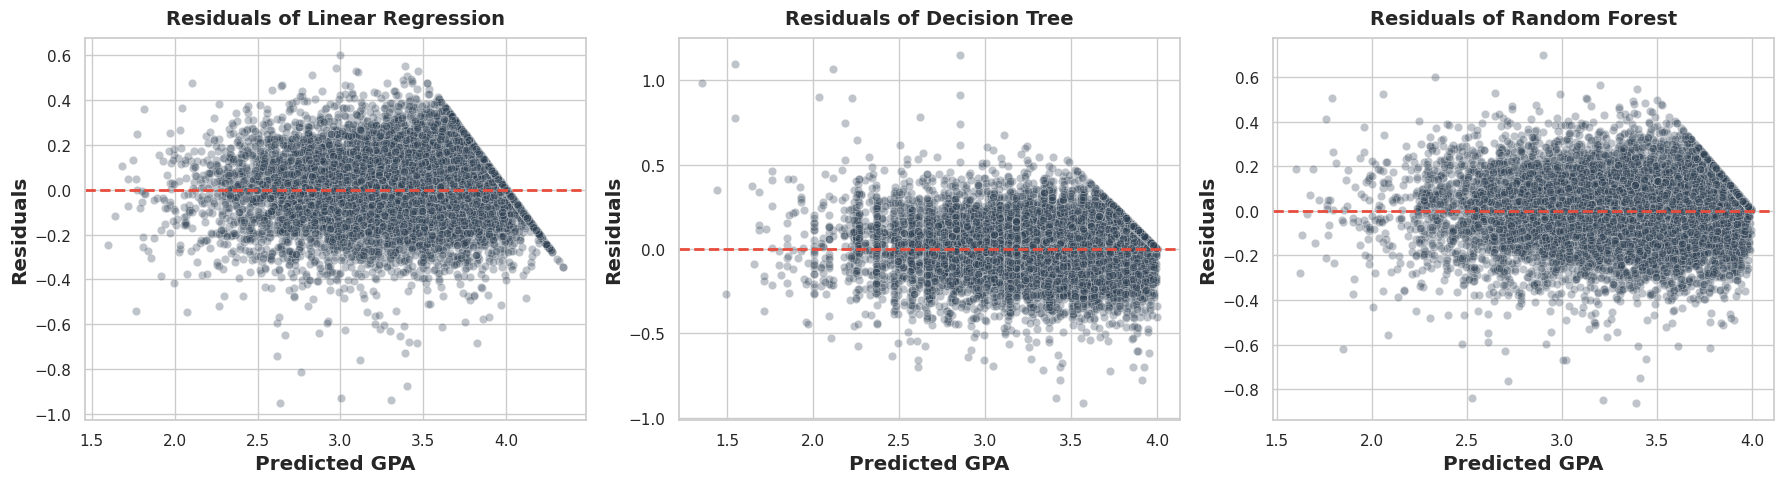

Kết quả của 3 mô hình: 
                      MAE    RMSE      R2
Linear Regression  0.1249  0.1594  0.8948
Decision Tree      0.1281  0.1679  0.8833
Random Forest      0.1191  0.1530  0.9030


In [7]:
# Cài đặt max_depth cho cây để tránh overfitting. n_jobs=-1 giúp Random Forest chạy nhanh hơn bằng cách dùng hết số lõi CPU
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
}


results = {}
plt.figure(figsize=(18, 5))

# Huấn luyện và vẽ biểu đồđồ Residual
for i, (name, model) in enumerate(models.items(), 1):
    # Tạo pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])

    # Huấn luyện
    pipeline.fit(X_train, y_train)

    # Dự đoán
    y_pred = pipeline.predict(X_test)

    # Tính các chỉ số đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    # Tính Phần dư (Residuals)
    residuals = y_test - y_pred

    # Vẽ biểu đồ Residual
    plt.subplot(1, 3, i)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='#2c3e50')
    plt.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)
    plt.title(f'Residuals of {name}')
    plt.xlabel('Predicted GPA')
    plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


print("Kết quả của 3 mô hình: ")
print(pd.DataFrame(results).T.round(4))

Nhận xét Biểu đồ Residual:

Khi nhìn vào 3 biểu đồ sinh ra từ đoạn code, ta thấy:

- Linear Regression: Các điểm phân bố thành một đám mây tương đối ngẫu nhiên quanh đường 0. Điều này cho thấy giả định tuyến tính ban đầu khá đúng đắn. Tuy nhiên, ở các mức GPA cực đoan (rất thấp hoặc rất cao), đám mây có xu hướng phình ra một chút xíu.

- Decision Tree: Biểu đồ phần dư có dạng hơi phân lớp (đường sọc ngang/dọc) do bản chất thuật toán phân tách dữ liệu thành các "nhánh" cố định. Các điểm dự đoán có sai số bị lệch xa so với đường 0 nhiều hơn.

- Random Forest: Đây là biểu đồ có đám mây điểm co cụm dày đặc và bám sát đường màu đỏ 0 nhất. Không có quy luật hình học (phễu hay uốn cong) nào rõ rệt, chứng tỏ mô hình đã "bắt" được các mối quan hệ phi tuyến tính mà Linear Regression không làm được, đồng thời loại bỏ được độ nhiễu của Decision Tree đơn lẻ.


## Problem 2: Burn-Out Risk Level Prediction (Classification) (Phát)

Yêu cầu:
- Tự chọn các cột cần thiết, phù hợp cho bài toán
- Huấn luyện 3 mô hình và tìm tham số để tối ưu cho từng mô hình
- Đánh giá mô hình bằng các chỉ số `Accuracy,Precision,Recall` và nhận xét Confusion Matrix
- Viết thêm file `report.md` để nhận xét kết quả và so sánh mô hình.

## Problem 3: Behavior Clustering (Unsupervised) (Thành)

Yêu cầu:
- Chọn các cột phù hợp để gom nhóm phân loại các học sinh
- Áp dụng thuật toán K-Means
- Chọn số cụm k bằng các phương pháp Elbow, Silhouette.
- Vẽ biểu đồ đánh giá cụm bằng các chỉ số Silhouette, Calinski-Harabasz, Davies-Bouldin và nhận xét